In [9]:
import torch
import json
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from clearml import Task, Logger
import matplotlib.pyplot as plt

In [3]:
with open("creds.json", "r") as lines:
    creds = json.load(lines)

Task.set_credentials(
    api_host=creds["api_server"],
    web_host=creds["web_server"],
    files_host=creds["files_server"],
    key=creds["access_key"],
    secret=creds["secret_key"]
)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# dataset = MNIST(root='./data', train=True, download=True, transform=transform)
# train_size = int(0.8 * len(dataset))
# val_size   = len(dataset) - train_size
train_dataset = MNIST(root='./data', train=True, download=False, transform=transform)
test_dataset  = MNIST(root='./data', train=False, download=False, transform=transform)

# train_data, val_data = random_split(dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,   batch_size=1000, shuffle=False)

---
## MLP 28x28 -> 32 -> 10

In [5]:
# Название модели для отображения графиков и логирования
name = 'MLP_1layer'
# Последовательность самой модели
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 10)
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

task = Task.init(project_name='NeuralNetworkCourse',
                 task_name=name,
                 reuse_last_task_id=False)
logger = Logger.current_logger()

ClearML Task: created new task id=20ea7bd88cc546109102a4c48554142d


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/714754e5866f4c8e84538742b4ecfb1a/experiments/20ea7bd88cc546109102a4c48554142d/output/log


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [6]:

num_epochs = 5
hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }

for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)

    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)

    # Логирование в ClearML 
    logger.report_scalar("Loss", "Train", epoch_train_loss, epoch)
    logger.report_scalar("Loss", "Validation", epoch_val_loss, epoch)
    logger.report_scalar("Accuracy", "Validation", epoch_val_acc, epoch)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")

task.close()

MLP_1layer Epoch 1/5 - Train Loss: 0.3702, Val Loss: 0.2375, Val Acc: 93.14%
MLP_1layer Epoch 2/5 - Train Loss: 0.2118, Val Loss: 0.1728, Val Acc: 94.67%
MLP_1layer Epoch 3/5 - Train Loss: 0.1682, Val Loss: 0.1555, Val Acc: 95.27%
MLP_1layer Epoch 4/5 - Train Loss: 0.1443, Val Loss: 0.1405, Val Acc: 95.77%
MLP_1layer Epoch 5/5 - Train Loss: 0.1281, Val Loss: 0.1329, Val Acc: 95.85%


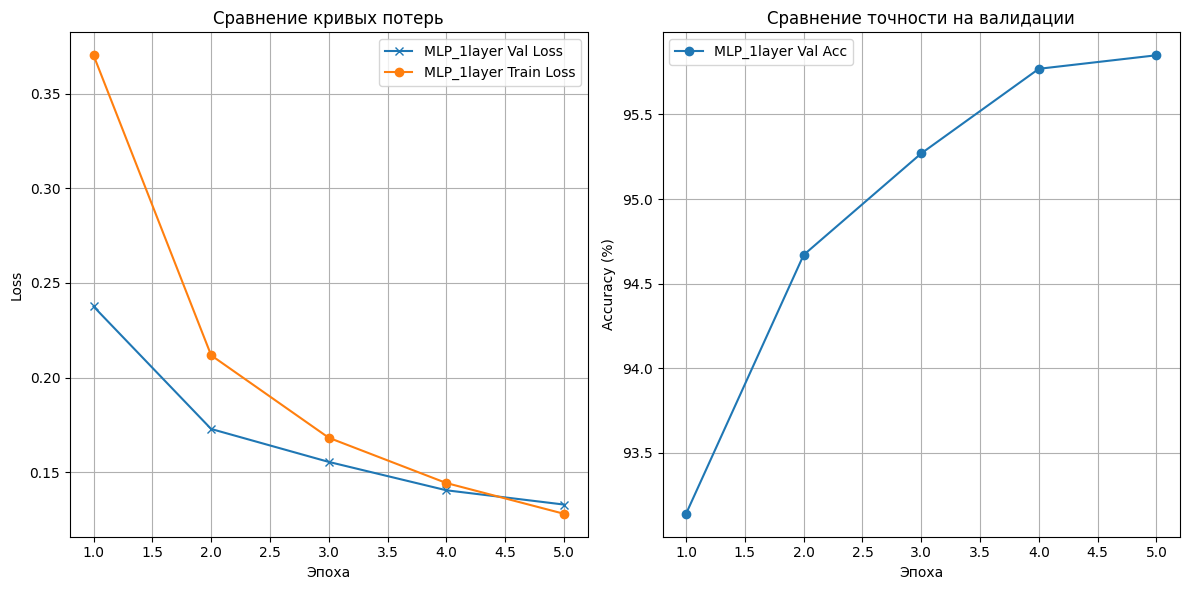

'https://app.clear.ml/projects/714754e5866f4c8e84538742b4ecfb1a/experiments/20ea7bd88cc546109102a4c48554142d/output/log'

In [13]:
# Визуализация истории обучения (пример для loss)
plt.figure(figsize=(12, 6))


# Потеря
plt.subplot(1, 2, 1)
epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_loss'],   marker='x', label=f"{name} Val Loss")
plt.plot(epochs, hist[name]['train_loss'], marker='o', label=f"{name} Train Loss",)
plt.title("Сравнение кривых потерь")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)


# Точность
plt.subplot(1, 2, 2)


epochs = range(1, num_epochs + 1)
plt.plot(epochs, hist[name]['val_acc'], marker='o', label=f"{name} Val Acc")
plt.title("Сравнение точности на валидации")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

task.get_output_log_web_page()

---
## MLP 28x28 → 16 → 10

In [14]:
# Название модели для отображения графиков и логирования
name = 'MLP_1layer_16'
# Последовательность самой модели
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 16),
    torch.nn.ReLU(),
    torch.nn.Linear(16, 10)
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

task = Task.init(project_name='NeuralNetworkCourse',
                 task_name=name,
                 reuse_last_task_id=False)
logger = Logger.current_logger()

ClearML Task: created new task id=ae694faf4ead4a029a18e7642ba678fc


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/714754e5866f4c8e84538742b4ecfb1a/experiments/ae694faf4ead4a029a18e7642ba678fc/output/log


ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring


In [15]:
num_epochs = 5
hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }

for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)

    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)

    # Логирование в ClearML 
    logger.report_scalar("Loss", "Train", epoch_train_loss, epoch)
    logger.report_scalar("Loss", "Validation", epoch_val_loss, epoch)
    logger.report_scalar("Accuracy", "Validation", epoch_val_acc, epoch)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")

task.close()

MLP_1layer_16 Epoch 1/5 - Train Loss: 0.4082, Val Loss: 0.2662, Val Acc: 92.55%
MLP_1layer_16 Epoch 2/5 - Train Loss: 0.2482, Val Loss: 0.2167, Val Acc: 93.55%
MLP_1layer_16 Epoch 3/5 - Train Loss: 0.2125, Val Loss: 0.1990, Val Acc: 94.19%
MLP_1layer_16 Epoch 4/5 - Train Loss: 0.1896, Val Loss: 0.1883, Val Acc: 94.36%
MLP_1layer_16 Epoch 5/5 - Train Loss: 0.1745, Val Loss: 0.1782, Val Acc: 94.90%


---
## MLP 28x28 → 128 → 64 → 10

In [16]:
# Название модели для отображения графиков и логирования
name = 'MLP_1layer_128_64'
# Последовательность самой модели
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 10)
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

task = Task.init(project_name='NeuralNetworkCourse',
                 task_name=name,
                 reuse_last_task_id=False)
logger = Logger.current_logger()

ClearML Task: created new task id=0b109d60212948e2b2f237eda186e731


Could not fetch GPU stats: NVML Shared Library Not Found


ClearML results page: https://app.clear.ml/projects/714754e5866f4c8e84538742b4ecfb1a/experiments/0b109d60212948e2b2f237eda186e731/output/log


In [17]:
num_epochs = 5
hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }

for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)

    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)

    # Логирование в ClearML 
    logger.report_scalar("Loss", "Train", epoch_train_loss, epoch)
    logger.report_scalar("Loss", "Validation", epoch_val_loss, epoch)
    logger.report_scalar("Accuracy", "Validation", epoch_val_acc, epoch)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")

task.close()
task.get_output_log_web_page()

ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
MLP_1layer_128_64 Epoch 1/5 - Train Loss: 0.2665, Val Loss: 0.1462, Val Acc: 95.51%
MLP_1layer_128_64 Epoch 2/5 - Train Loss: 0.1108, Val Loss: 0.0942, Val Acc: 97.09%
MLP_1layer_128_64 Epoch 3/5 - Train Loss: 0.0770, Val Loss: 0.0845, Val Acc: 97.35%
MLP_1layer_128_64 Epoch 4/5 - Train Loss: 0.0593, Val Loss: 0.0960, Val Acc: 97.02%
MLP_1layer_128_64 Epoch 5/5 - Train Loss: 0.0470, Val Loss: 0.0786, Val Acc: 97.71%


'https://app.clear.ml/projects/714754e5866f4c8e84538742b4ecfb1a/experiments/0b109d60212948e2b2f237eda186e731/output/log'

---
## MLP 28x28 → 256 → 128 → 64 → 10

In [20]:
# Название модели для отображения графиков и логирования
name = 'MLP_3layer_256_128_64'
# Последовательность самой модели
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(784, 256),
    torch.nn.BatchNorm1d(256),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.5),
    torch.nn.Linear(256, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, 10)
)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

task = Task.init(project_name='NeuralNetworkCourse',
                 task_name=name,
                 reuse_last_task_id=False)
logger = Logger.current_logger()

In [21]:
num_epochs = 5
hist = {name: {'train_loss': [], 'val_loss': [], 'val_acc': []} }

for epoch in range(1, num_epochs + 1):
    # Обучение
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_train_loss = running_loss / len(train_loader)
    # Добавляем потерю для графика
    hist[name]['train_loss'].append(epoch_train_loss)

    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    # В этот раз посчитаем валидацию на каждой эпохе обучения
    epoch_val_loss = val_loss / len(test_loader)
    epoch_val_acc  = 100.0 * correct / total
    # Добавляем потерю для графика
    hist[name]['val_loss'].append(epoch_val_loss)
    # Добавляем точность для графика
    hist[name]['val_acc'].append(epoch_val_acc)

    # Логирование в ClearML 
    logger.report_scalar("Loss", "Train", epoch_train_loss, epoch)
    logger.report_scalar("Loss", "Validation", epoch_val_loss, epoch)
    logger.report_scalar("Accuracy", "Validation", epoch_val_acc, epoch)

    print(f"{name} Epoch {epoch}/{num_epochs} - "
            f"Train Loss: {epoch_train_loss:.4f}, "
            f"Val Loss: {epoch_val_loss:.4f}, "
            f"Val Acc: {epoch_val_acc:.2f}%")

task.close()
task.get_output_log_web_page()

MLP_3layer_256_128_64 Epoch 1/5 - Train Loss: 0.3372, Val Loss: 0.1335, Val Acc: 95.88%
MLP_3layer_256_128_64 Epoch 2/5 - Train Loss: 0.1867, Val Loss: 0.0955, Val Acc: 97.03%
MLP_3layer_256_128_64 Epoch 3/5 - Train Loss: 0.1515, Val Loss: 0.0872, Val Acc: 97.36%
MLP_3layer_256_128_64 Epoch 4/5 - Train Loss: 0.1306, Val Loss: 0.0785, Val Acc: 97.56%
MLP_3layer_256_128_64 Epoch 5/5 - Train Loss: 0.1223, Val Loss: 0.0765, Val Acc: 97.63%


'https://app.clear.ml/projects/714754e5866f4c8e84538742b4ecfb1a/experiments/83ec24d5dfe24c86a4e9cc732a140621/output/log'

In [23]:
model_state = {
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}
torch.save(model_state, 'model_state.checkpoint')
torch.save(model, 'full.model')